In [10]:
import gdown
gdown.download('https://bit.ly/3736JW1', 'ns_book6.csv', quiet=False)

Downloading...
From: https://bit.ly/3736JW1
To: /content/ns_book6.csv
100%|██████████| 55.0M/55.0M [00:00<00:00, 98.8MB/s]


'ns_book6.csv'

In [11]:
import pandas as pd
ns_book6 = pd.read_csv('ns_book6.csv', low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021.0,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021.0,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021.0,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021.0,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021.0,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


판다스는 데이터프레임에서 기본적인 몇 가지 기술통계를 자동으로 추출해주는 describe() 메서드를 제공

In [12]:
ns_book6.describe()

,번호,발행년도,도서권수,대출건수
count,379976.000000,379976.000000,379976.000000,379976.000000
mean,201726.332847,2008.516306,1.135874,11.504629
std,115836.454596,8.780529,0.483343,19.241926
min,1.000000,1947.000000,0.000000,0.000000
25%,102202.750000,2003.000000,1.000000,2.000000
50%,203179.500000,2009.000000,1.000000,6.000000
75%,301630.250000,2015.000000,1.000000,14.000000
max,401681.000000,2650.000000,40.000000,1765.000000


describe()메서드는 기본적으로 수치형 열에 대한 요약 통계를 보여줍니다. 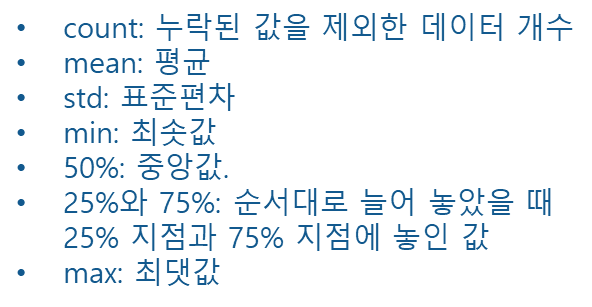

이상한 점: 도서권수 최솟값이 0, 도서를 한 권도 가지고 있지 않은데 대출 대이터에 포함됨

이런 도서가 많다면 이를 걸러내야 할지 고려해야 함

**불리언배열과 sum()함수**를 활용하면 도서권수가 0인 도서의 행 개수를 쉽게 카운트 가능

In [13]:
sum(ns_book6['도서권수']==0)

3206

3천개가 넘는 도서권수가 0

전체 데이터에 비해 1%가 채 안되기 때문에 무시할만한 수치이지만 이런 도서가 많다면 데이터 분석에서 제외할지 판단해야 함

처리기준: 해결할 문제에 따라 다르며 이러한 결정이 분석 결과에 큰 영향을 미칠 수도 있음

In [14]:
ns_book7 = ns_book6[ns_book6['도서권수']>0]

다시 기술 통계를 출력해보면 describe()메서드는 기본적으로 25%,50%,75%에 위치한 값을 보여줌

원하는 위치에 값을 보고 싶다면 percentiles 매개변수에 위치를 지정

In [16]:
# ex
ns_book7.describe(percentiles=[0.3, 0.6, 0.9])

,번호,발행년도,도서권수,대출건수
count,376770.000000,376770.000000,376770.000000,376770.000000
mean,202977.476649,2008.460076,1.145540,11.593439
std,115298.245784,8.773148,0.473853,19.279409
min,1.000000,1947.000000,1.000000,0.000000
30%,124649.700000,2004.000000,1.000000,2.000000
50%,204550.500000,2009.000000,1.000000,6.000000
60%,243537.400000,2011.000000,1.000000,8.000000
90%,361341.100000,2018.000000,2.000000,28.000000
max,401681.000000,2650.000000,40.000000,1765.000000


열의 데이터 타입이 수치가 아닌 다른 데이터 타입의 열의 기술통계를 보고 싶다면 include 매개변수의 데이터 타입을 지정할 수도 있음

In [17]:
# ex
ns_book7.describe(include='object')

,도서명,저자,출판사,ISBN,세트 ISBN,부가기호,권,주제분류번호,등록일자
count,376770,376770,376770,376770,55866,308252,61793,359792,376770
unique,336408,248850,21875,350810,14875,17,834,12467,4562
top,승정원일기,세종대왕기념사업회 [편],문학동네,9788937430299,9788937460005,0,1,813.6,1970-01-01
freq,250,303,4410,206,702,158235,13282,14816,28185


- count행: 누락된 값을 제외한 데이터 개수
- unique행: 고유한 값의 개수
- top행: 가장 많이 등장하는 값
- freq행: top행에 등장하는 항목의 빈도수

실행 결과: 도서명 열에서 가장 많이 등장하는 데이터 = 승정원 일기(250회)

# 평균

$평균 = \dfrac{a + b + c}{3}$

$평균 = \dfrac{x_1 + x_2 + x_3}{3}$

In [18]:
x = [10, 20, 30]
sum = 0
for i in range(3):
  sum += x[i]
print('평균:', sum/len(x))

평균: 20.0


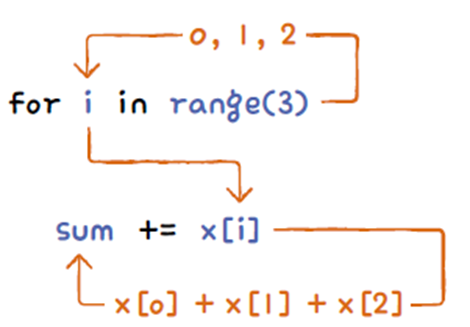

$평균 = \dfrac{x_1 + x_2 + x_3}{3} = \dfrac{\sum_{i=1}^{3} x_i}{3}$

$평균 대출건수 = \dfrac{\sum_{i=1}^{376770} x_i}{376770}$

판다스 데이터프레임과 시리즈 객체: 평균을 계산하는 mean() 메서드 제공

In [19]:
# 평균 대출 건수
ns_book7['대출건수'].mean()

np.float64(11.593438968070707)

# 중앙값(median)

데이터를 순서대로 늘어 놓았을 때 중앙에 위치한 값, 50% 위치의 값이 중앙값에 해당

In [20]:
# 판다스의 중앙값 메서드
ns_book7['대출건수'].median()

6.0

데이터 개수가 홀수일 경우?

In [21]:
temp_df = pd.DataFrame([1,2,3,4])
temp_df.median()

,0
0,2.5


데이터 개수가 짝수이면 두 개의 값을 평균하여 중앙값을 결정

## 중복값 제거하고 중앙값 구하기

In [22]:
# drop_duplicate() 사용
ns_book7['대출건수'].drop_duplicates().median()

183.0

중복된 값을 제거하니 중앙값이 엄청 높아짐

-> 작은 대출건수에 중복된 행이 많다고 생각할 수 있음

# 최솟값, 최댓값

중앙값과 함께 자주 사용되는 통계랑
- 판다스에서는 각각 min() 메서드와 max() 메서드 제공

In [23]:
ns_book7['대출건수'].min()

0

In [24]:
ns_book7['대출건수'].max()

1765

# 분위수

데이터를 순서대로 늘어 놓았을 때 균등한 간격으로 나누는 기준점
- ex. 이분위수는 전체 데이터를 두 구간으로 나눔 -> 중앙값에 해당
- 많이 사용하는 사분위수는 순서대로 정렬된 데이터를 네 구간으로 나눔
- 따라서 사분위수는 3개가 나오고 각각 25%,50%,75%에 해당
- 25%: 제1사분위수, 중앙값: 제2사분위수, 75%: 제3사분위수

분위수는 데이터를 순서대로 늘어 놓았을 때 이를 균등한 간격으로 나누는 기준점입니다.

예를 들어 이분위수는 전체 데이터를 두 구간으로 나누기 때무에 중앙값에 해당합니다.

많이 사용하는 사분위수는 순서대로 정렬된 데이터를 네 구간으로 나눕니다.

따라서 사분위수는 3개가 나오고 각각 25%, 50%, 75%에 해당합니다.

25%에 대항하는 값을 제 1 사분위수,

중앙값을 제2사분위수, 75%에 해당하는 값을 제3사분위수라고도 부릅니다.
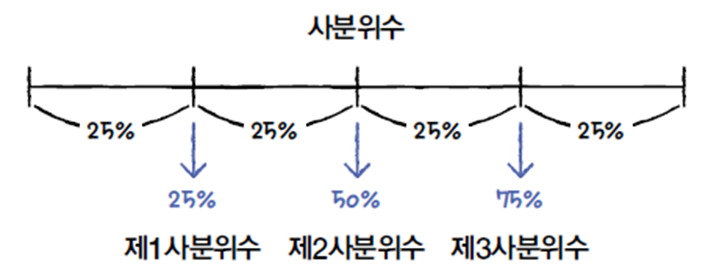

## quantile() 메서드

In [25]:
# 판다스에서 분위수 값을 계산할 때 사용
# 하위 25%에 위치한 값을 출력 -> 0.25 입력

ns_book7['대출건수'].quantile(0.25)

np.float64(2.0)

여러개의 분위수를 지정할 수도 있음

In [26]:
ns_book7['대출건수'].quantile([0.25, 0.5, 0.75])

,대출건수
0.25,2.0
0.50,6.0
0.75,14.0


In [27]:
# 1,2,3,4,5 다섯 개의 숫자가 있을 때 90% 위치에 있는 값?
# 시리즈 객체를 정의한 후 분위수 구하기
pd.Series([1,2,3,4,5]).quantile(0.9)

np.float64(4.6)

quantile() 메서드는 interpolation 매개변수에서 중간값을 계산하는 방법을 결정 \
위 코드는 interpolation 매개변수를 따로 지정하지 않아서 기본값으로 계산됨

ex. 4와 5 사이에서 90% 해당하는 분위수를 찾을 때, 다음 그림처럼 4의 분위수가 0.75와 5의 분위수 1.0을 사용해 간단한 비례식을 세울 수 있음

quantile()메서드는 **interpolation매개변수**에서 중간 값을 계산하는 방법을 결정합니다.

위 코드는 interpolatoin매개변수를 따로 지정하지 않아서 기본값으로 계산되었습니다.

예를 들어 4와 5사이에서 90%에 해당하는 분위수를 찾을때, 다음그림처럼 4의 분위수 0.75와 5의 분위수 1.0을 사용해 간단한 비례식을 세울 수 있습니다.

여기서 궁금한 값 b에 대해 정리하면 아래와 같은 식을 얻게 됩니다.

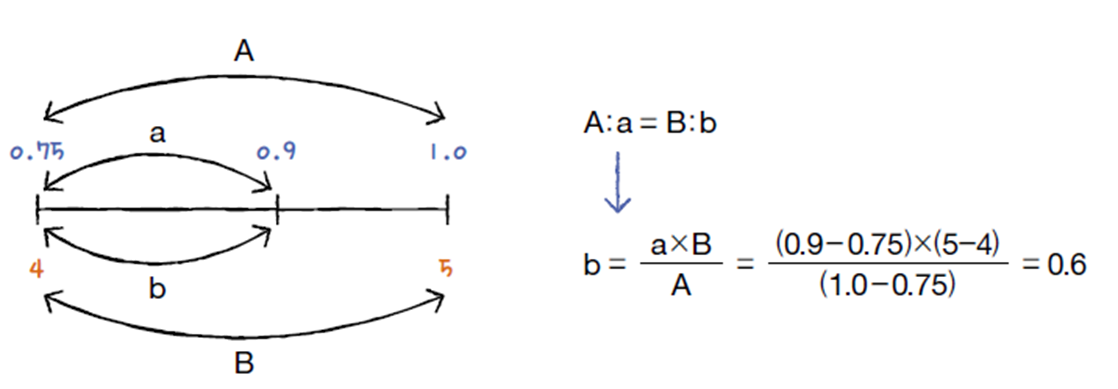
이렇게 두 지점 사이에 놓인 특정 위치의 값을 구하는 방법을

보간(interploation)이라고 함



In [28]:
4 + (0.9-0.75) * (5-4)/(1.0-0.75)

4.6

In [29]:
pd.Series([1,2,3,4,5]).quantile(0.9,interpolation='midpoint')

np.float64(4.5)

interpolation 매개변수는 'linear' 외에도 여러가지 다른 보간 방식을 제공 \/
'midpoint'는 분위수에 상관없이 무조건 두 수 사이의 중앙값을 사용

In [30]:
pd.Series([1,2,3,4,5]).quantile(0.9,interpolation='nearest')

np.int64(5)

'nearest' = 두 수 중에서 가까운 값을 선택 \
이 경우 0.9가 1.0에 더 가깝기 때문에 5가 됨

## 백분위 구하기

데이터가 작을 때는 직접 쉽게 헤아려 구할 수 있지만 데이터가 많으면 어려움

1. 대출건수열의 값이 10보다 작은지 비교하여 **불리언 배열** 만들기

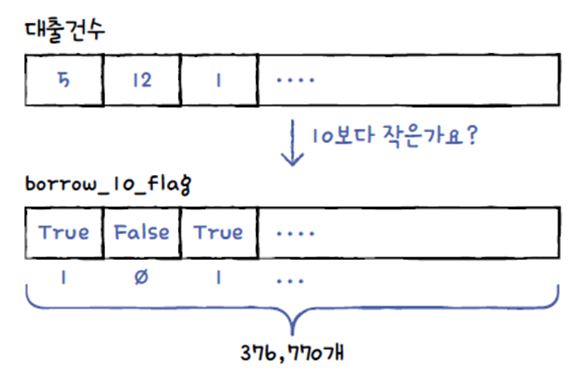

In [31]:
borrow_10_flag = ns_book7['대출건수'] < 10

불리언 배열에서는 True가 1, False가 0으로 계산됨.
그래서 borrow_10_flag.mean()을 하면 True의 비율 = 즉 10보다 작은 대출 건수의 비율을 한 번에 구할 수 있음.
데이터 개수가 많을수록 이 값은 10의 백분위 위치와 거의 비슷하게 나타남.

In [32]:
borrow_10_flag.mean()

np.float64(0.6402712530190833)

10에 대한 백분위는 약 0.65

In [33]:
# quantile()메서드에 백분위를 넣어 직접 확인해보면 기대했던 10 출력됨
ns_book7['대출건수'].quantile(0.65)

np.float64(10.0)

# 분산

평균으로부터 데이터가 얼마나 퍼져있는지를 나타내는 통계량

데이터가 가운데 모여 있다면 분산이 작고 넓게 퍼져있다면 분산이 큼.
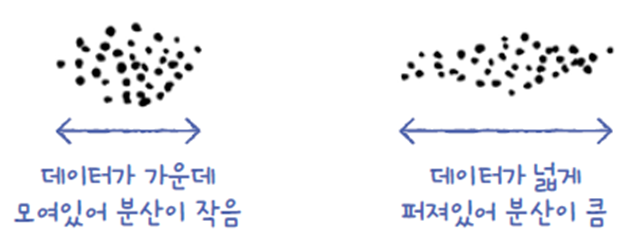

분산은 데이터의 각 값에서 평균을 뺀 다음 제곱한 후 평균처럼 샘플 개수로 나누어 구할 수 있음
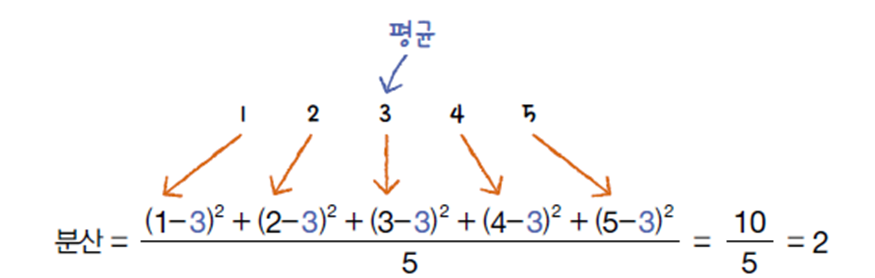

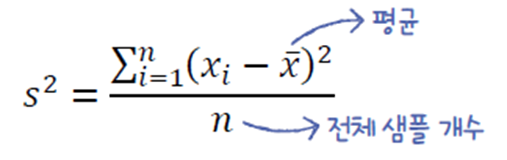

$ s^2 = \dfrac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n}$

$ \bar{x} = \dfrac{\sum_{i=1}^n x_i}{n}$

In [34]:
ns_book7['대출건수'].var()

371.6956304306922

분산은 데이터가 평균으로부터 얼마나 퍼져있는지를 나타내는 값임.
다만 값 자체만 보고 크고 작은지를 바로 판단하기는 어려움.

또 분산은 편차를 제곱해서 계산하기 때문에 평균에서 멀리 떨어진 값일수록 영향이 더 커짐.
게다가 단위도 원래 데이터의 제곱 형태가 되어 해석이 직관적이지 않음.

그래서 보통은 분산에 제곱근을 씌운 표준편차를 더 많이 사용함.

# 표준편차 구하기

분산에 제곱근을 한 것으로 수식 기호는 s

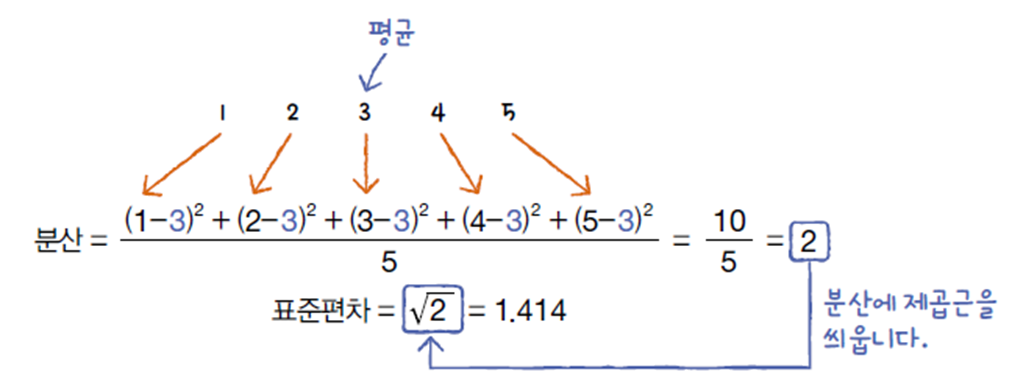

$ s = \sqrt{\dfrac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n}}$

$\sqrt{4}=2$

In [35]:
ns_book7['대출건수'].std()

19.27940949382766

평균 대출 건수는 약 11회 정도였는데 표준편차가 19라는 것은,
도서별 대출 건수가 평균보다 훨씬 크거나 작은 경우가 많다는 뜻임.

보통 표준편차는 평균을 기준으로 데이터가 얼마나 퍼져 있는지 보여주는데,
평균보다 표준편차가 너무 크기 때문에 데이터 분포가 많이 치우쳐 있다고 볼 수 있음.

특히 대출 건수는 음수가 될 수 없는데 평균 11에서 표준편차가 19이면 비정상적으로 크게 느껴짐.
즉 일부 도서의 대출 건수가 매우 높아서 전체 표준편차를 크게 만든 것으로 예상할 수 있음.

## 수식 코드로 구현

판다스와 넘파이를 사용해 표준편차를 수식대로 직접 계산해서 판다스의 std()메서드를 사용한 결과와 동일한지 확인
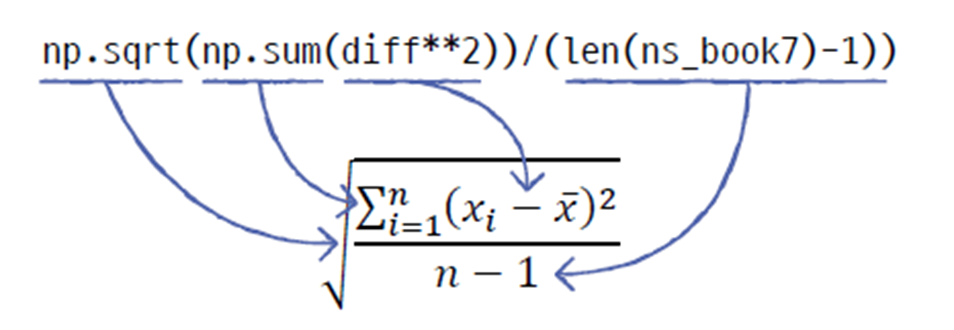

In [36]:
import numpy as np

diff = ns_book7['대출건수'] - ns_book7['대출건수'].mean()

np.sqrt( np.sum(diff**2) / (len(ns_book7)-1) )

np.float64(19.279409493785508)

# 최빈값 구하기

최빈값(mode)은 데이터에서 가장 많이 등장한 값을 의미함.
즉 데이터 안에서 가장 자주 나온 값이라고 보면 됨.

판다스에서 describe(include='object')를 실행했을 때 나오는 top 행이 바로 최빈값을 나타냄.
판다스의 mode() 메서드는 데이터의 최빈값을 구할 때 사용함.
도서명 컬럼에 적용해 보면 describe() 메서드의 top 값과 동일하게 나오는 것을 확인할 수 있음.

In [37]:
ns_book7['도서명'].mode()

,도서명
0,승정원일기


이런 메서드들은 대부분 판다스 데이터프레임에서도 직접 호출 가능

#데이터프레임에서 기술통계 구하기

지금까지 평균, 중앙값, 최솟값, 최댓값, 분위수, 분산, 표준편차 등을 구하는 다양한 판다스 메서드를 알아봄.

이 메서드들은 데이터프레임 전체에도 사용할 수 있는데, 수치형 데이터만 계산 가능하기 때문에 numeric_only=True 옵션을 지정해주는 것이 좋음.

예를 들어 ns_book7.mean(numeric_only=True)처럼 사용하면 숫자형 열들에 대해서만 평균이 계산됨.

만약 numeric_only를 지정하지 않으면 문자열 같은 비수치형 열까지 함께 처리하려고 시도해서 실행 시간이 오래 걸리거나 경고가 발생할 수 있음.

In [38]:
ns_book7.mean(numeric_only=True)

,0
번호,202977.476649
발행년도,2008.460076
도서권수,1.145540
대출건수,11.593439


mode() 메서드도 데이터프레임 전체에서 사용할 수 있음.

다만 ns_book7의 '번호' 열처럼 모든 값이 고유한 경우에는 최빈값을 구하는 의미가 거의 없음.

그래서 보통은 loc 메서드를 사용해서 '도서명' 열부터 마지막 열까지만 선택한 뒤 최빈값을 구함.

In [39]:
ns_book7.loc[:, '도서명':].mode()

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012.0,9788937430299,9788937460005,0,1,813.6,1,0,1970-01-01


'도서명' 열의 최빈값은 '승정원일기'이고, '출판사' 열의 최빈값은 '문학동네'임.

하지만 이 결과만 보고 승정원일기가 문학동네에서 출판된 책이라고 해석하면 안 됨.

mode() 메서드는 각 열별로 최빈값을 따로 계산한 결과이기 때문에, 출력된 값들끼리는 서로 연관이 없음에 주의해야 함.

In [42]:
# csv 파일로 저장
ns_book7.to_csv('ns_book7.csv', index=False)

# 넘파이의 기술통계 함수

## 평균 구하기

In [43]:
import numpy as np
np.mean(ns_book7['대출건수'])

np.float64(11.593438968070707)

$\dfrac{국어점수 \times 2 + 수학점수}{3}$

$\dfrac{국어점수 \times 국어가중치 + 수학점수 \times 수학가중치}{국어가중치 + 수학가중치}$

$가중평균 = \dfrac{x_1 \times w_1 + x_2 \times w_2}{w_1 + w_2} = \dfrac{\sum_{i=1}^{2} x_i \times w_i}{\sum_{i=1}^{2} w_i}$

In [44]:
np.average(ns_book7['대출건수'], weights=1/ns_book7['도서권수'])

np.float64(10.543612175385386)

In [45]:
np.mean(ns_book7['대출건수']/ns_book7['도서권수'])

np.float64(9.873029861445774)

In [46]:
ns_book7['대출건수'].sum()/ns_book7['도서권수'].sum()

np.float64(10.120503701300958)

##중앙값 구하기


In [47]:
np.median(ns_book7['대출건수'])

np.float64(6.0)

## 최솟값, 최댓값 구하기

In [48]:
np.min(ns_book7['대출건수'])

0

In [49]:
np.max(ns_book7['대출건수'])

1765

## 분위수 구하기

In [51]:
# interpolation 매개변수가 numpy 1.22(python >= 3.8) 버전부터 method로 바뀜
np.quantile(ns_book7['대출건수'], [0.25,0.5,0.75])

array([ 2.,  6., 14.])

## 분산 구하기

In [50]:
np.var(ns_book7['대출건수'])

371.694643898775

$ s^2 = \dfrac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n - 1}$

In [52]:
ns_book7['대출건수'].var(ddof=0)

371.694643898775

In [53]:
np.var(ns_book7['대출건수'], ddof=1)

371.6956304306922

## 표준 편차 구하기

In [54]:
np.std(ns_book7['대출건수'])

19.279383908693113

## 최빈값 구하기

In [55]:
values, counts = np.unique(ns_book7['도서명'], return_counts=True)
max_idx = np.argmax(counts)
values[max_idx]

'승정원일기'

# 확인문제

In [57]:
#4
ns_book7[['출판사','대출건수']].groupby('출판사').mean().sort_values('대출건수', ascending=False).head(10)

,대출건수
출판사,
동녁라이프,224.000000
와이비엠시사,215.000000
환상,210.000000
두앤비컨텐츠(랜덤하우스중앙),167.000000
개미들출판사-에셀문화사,157.000000
해커스 어학 연구소,149.500000
Test clinic,137.000000
마야출판사,133.333333
해밀 & Co.,133.000000


In [58]:
#5
target_range = np.array(ns_book7['대출건수'].quantile(q=[0.25,0.75]))
target_bool_idx = (ns_book7['대출건수'] >= target_range[0]) & (ns_book7['대출건수'] <= target_range[1])
target_bool_idx.sum()/len(ns_book7)*100

np.float64(51.51737134060568)